In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, LayerNormalization, GaussianNoise

In [15]:
#load csvs
benign_path = r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\Benign_train.pcap_Flow.csv"
connect_path = r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\MQTT-DDoS-Connect_Flood_train.pcap_Flow.csv"
publish_path = r"C:\Users\t0eur\OneDrive\Documents\CiCIOMT Data\flows\MQTT-DDoS-Publish_Flood_train.pcap_Flow.csv"

In [16]:
#features list
features = [
        'Protocol', 'Flow Duration',
        'Flow Bytes/s', 'Flow Packets/s', 'Down/Up Ratio',
        'Total Fwd Packet', 'Total Bwd packets',
        'Fwd Header Length', 'Bwd Header Length',
        'FWD Init Win Bytes', 'Bwd Init Win Bytes',
        'Fwd Seg Size Min', 'Fwd Segment Size Avg',
        'Subflow Fwd Bytes', 'Subflow Bwd Bytes',
        'Packet Length Min', 'Packet Length Mean',
        'Packet Length Max', 'Packet Length Std',
        'Packet Length Variance', 'Average Packet Size',
        'Fwd IAT Mean', 'Bwd IAT Mean',
        'Fwd IAT Total', 'Bwd IAT Total',
        'Flow IAT Mean',
        'SYN Flag Count', 'ACK Flag Count',
        'PSH Flag Count', 'RST Flag Count', 'FIN Flag Count'
    ]

WINDOW = 50

In [17]:
# df_all = pd.concat([
#     pd.read_csv(benign_path)[features].replace([np.inf, -np.inf], np.nan).fillna(0),
#     pd.read_csv(connect_path)[features].replace([np.inf, -np.inf], np.nan).fillna(0),
#     pd.read_csv(publish_path)[features].replace([np.inf, -np.inf], np.nan).fillna(0)
# ])
# scaler = MinMaxScaler()
# scaler.fit(df_all)

In [18]:
# Load raw data
df_benign_raw = pd.read_csv(benign_path)[features].replace([np.inf, -np.inf], np.nan).fillna(0)
df_connect_raw = pd.read_csv(connect_path)[features].replace([np.inf, -np.inf], np.nan).fillna(0)
df_publish_raw = pd.read_csv(publish_path)[features].replace([np.inf, -np.inf], np.nan).fillna(0)

In [19]:
scaler = MinMaxScaler()
scaler.fit(pd.concat([df_benign_raw, df_connect_raw, df_publish_raw], ignore_index=True))

MinMaxScaler()

In [20]:
# Scale each dataset
df_benign_scaled = pd.DataFrame(scaler.transform(df_benign_raw), columns=features)
df_connect_scaled = pd.DataFrame(scaler.transform(df_connect_raw), columns=features)
df_publish_scaled = pd.DataFrame(scaler.transform(df_publish_raw), columns=features)

In [21]:
# def load_and_sequence(path, class_label, features, scaler, window=10):
#     df = pd.read_csv(path).replace([np.inf, -np.inf], np.nan).fillna(0)
#     df[features] = scaler.transform(df[features])

#     X, y = [], []
#     for i in range(0, len(df) - window, window):
#         X.append(df.iloc[i:i+window][features].values)
#         y.append(class_label)
        
#     return np.array(X), np.array(y)


def create_sequences(df, class_label, window=36):
    X, y = [], []
    n_sequences = len(df) // window
    
    for i in range(n_sequences):
        start_idx = i * window
        end_idx = start_idx + window
        X.append(df.iloc[start_idx:end_idx].values)
        y.append(class_label)
    
    return np.array(X), np.array(y)

In [22]:
# Create sequences
X_benign, y_benign = create_sequences(df_benign_scaled, 0, window=WINDOW)
X_connect, y_connect = create_sequences(df_connect_scaled, 1, window=WINDOW)
X_publish, y_publish = create_sequences(df_publish_scaled, 1, window=WINDOW)

print(f"Sequence counts - Benign: {len(X_benign)}, Connect: {len(X_connect)}, Publish: {len(X_publish)}")

Sequence counts - Benign: 713, Connect: 67456, Publish: 8074


In [44]:
X_all = np.concatenate([X_benign, X_connect, X_publish])
y_all = np.concatenate([
    np.zeros(len(X_benign)),     
    np.ones(len(X_connect)),       
    np.ones(len(X_publish))       
])
print(f"\nTotal sequences: {len(X_all)}")
print(f"Benign: {np.sum(y_all == 0)} ({np.mean(y_all == 0)*100:.2f}%)")
print(f"DDoS:   {np.sum(y_all == 1)} ({np.mean(y_all == 1)*100:.2f}%)")


Total sequences: 76243
Benign: 713 (0.94%)
DDoS:   75530 (99.06%)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

In [46]:
print("Training windows:", X_train.shape, "Class balance:", np.unique(y_train, return_counts=True))
print("Testing windows:", X_test.shape, "Class balance:", np.unique(y_test, return_counts=True))

Training windows: (60994, 50, 31) Class balance: (array([0., 1.]), array([  570, 60424]))
Testing windows: (15249, 50, 31) Class balance: (array([0., 1.]), array([  143, 15106]))


In [47]:
# X_benign, y_benign = load_and_sequence(
#     benign_path, class_label=0, features=features, scaler=scaler, window=50
# )

# X_connect, y_connect = load_and_sequence(
#     connect_path, class_label=1, features=features, scaler=scaler, window=50
# )

# X_publish, y_publish = load_and_sequence(
#     publish_path, class_label=1, features=features, scaler=scaler, window=50
# )
# Apply trained scaler


In [48]:
# ddos undersample
# X_attack = np.concatenate([X_connect, X_publish])
# y_attack = np.ones(len(X_attack))

# attack_target = 10000

# X_attack_small, y_attack_small = resample(
#     X_attack, y_attack,
#     replace=False,
#     n_samples=attack_target,
#     random_state=42
# )

In [49]:
# # final dataset
# # X = np.concatenate([X_benign, X_attack_small])
# # y = np.concatenate([y_benign, y_attack_small
# X = np.concatenate([X_benign, X_attack])
# y = np.concatenate([y_benign, y_attack])
# print(f"Final dataset: {X.shape}")

In [50]:
print("Unique labels in y_train:", np.unique(y_train, return_counts=True))

Unique labels in y_train: (array([0., 1.]), array([  570, 60424]))


In [52]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_all),
    y=y_all
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nComputed class weights: {class_weight_dict}")
print(f"  Benign weight: {class_weight_dict[0]:.2f}")
print(f"  DDoS weight:   {class_weight_dict[1]:.2f}")



Computed class weights: {0: np.float64(53.46633941093969), 1: np.float64(0.5047199788163643)}
  Benign weight: 53.47
  DDoS weight:   0.50


In [53]:
# model
timesteps = X_train.shape[1]
num_features = X_train.shape[2]

model = Sequential([
    LSTM(
        64,  
        input_shape=(timesteps, num_features),
        return_sequences=True, 
        dropout=0.2,
        recurrent_dropout=0.2,
    ),
    
    tf.keras.layers.GlobalAveragePooling1D(),
    
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    Dense(16, activation='relu'),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])
model.summary()

C:\Users\t0eur\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50, 64)         │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,201 (106.25 KB)

 Trainable params: 27,201 (106.25 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(
    optimizer='Adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


In [55]:
from tensorflow.keras.callbacks import EarlyStopping

callback = EarlyStopping(           
    patience=3,                   
    restore_best_weights=True,    
    verbose=1                     
)

In [58]:
history = model.fit(X_train, y_train,validation_split=0.2,epochs=10,batch_size=32,callbacks=[callback], class_weight=class_weight_dict, verbose=1) #

Epoch 1/10
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 52s 32ms/step - accuracy: 0.9940 - loss: 0.0475 - precision_1: 0.9999 - recall_1: 0.9940 - val_accuracy: 0.9999 - val_loss: 0.0021 - val_precision_1: 1.0000 - val_recall_1: 0.9999
Epoch 2/10
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9973 - loss: 0.0323 - precision_1: 0.9999 - recall_1: 0.9973 - val_accuracy: 0.9999 - val_loss: 5.8299e-04 - val_precision_1: 1.0000 - val_recall_1: 0.9999
Epoch 3/10
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9984 - loss: 0.0159 - precision_1: 1.0000 - recall_1: 0.9984 - val_accuracy: 0.9999 - val_loss: 8.5732e-04 - val_precision_1: 1.0000 - val_recall_1: 0.9999
Epoch 4/10
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9992 - loss: 0.0135 - precision_1: 1.0000 - recall_1: 0.9993 - val_accuracy: 0.9999 - val_loss: 7.3361e-04 - val_precision_1: 1.0000 - val_recall_1: 0.9999
Epoch 5/10
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.9984 - loss: 0.0094 - precisio

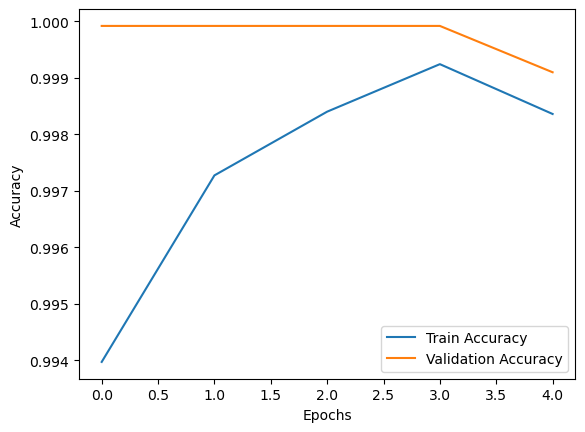

In [59]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

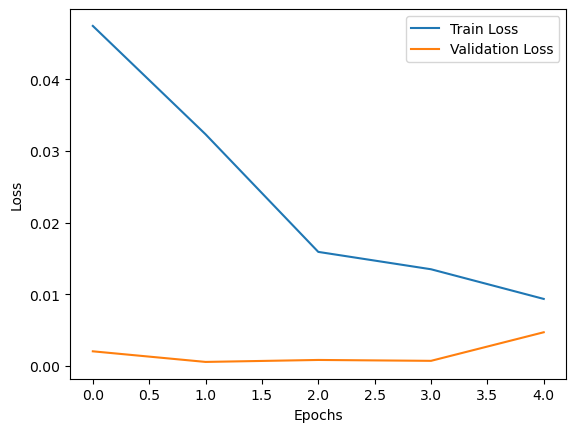

In [60]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

477/477 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
[[  143     0]
 [    2 15104]]
              precision    recall  f1-score   support

         0.0     0.9862    1.0000    0.9931       143
         1.0     1.0000    0.9999    0.9999     15106

    accuracy                         0.9999     15249
   macro avg     0.9931    0.9999    0.9965     15249
weighted avg     0.9999    0.9999    0.9999     15249



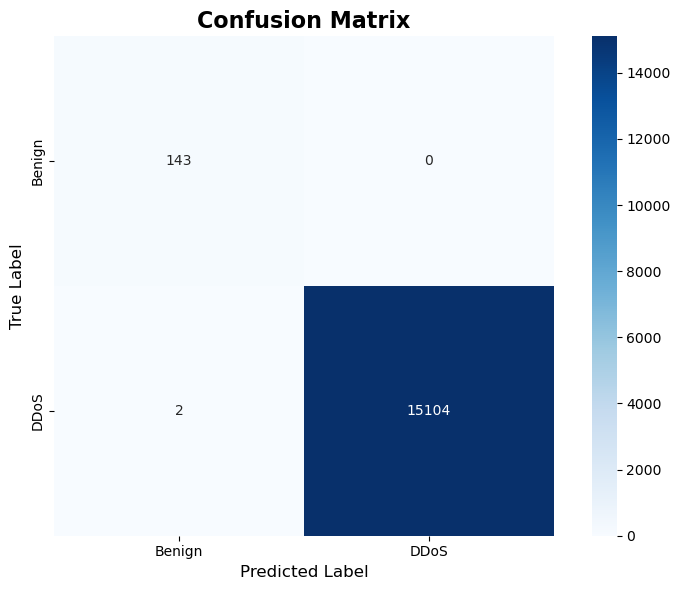

In [61]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'DDoS'],
            yticklabels=['Benign', 'DDoS'],
            cbar=True, 
            square=True)

plt.title('Confusion Matrix', fontsize=16, weight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
# import pickle
# # Save model and scaler
# with open('LSTM_model.pkl', 'wb') as f:
#     pickle.dump(model, f)

# with open('lstm_scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# print("\nModel and scaler saved!")


In [40]:
import hashlib

def hash_window(w):
    return hashlib.sha1(w.tobytes()).hexdigest()

train_hashes = {hash_window(w) for w in X_train}
test_hashes  = {hash_window(w) for w in X_test}

len(train_hashes & test_hashes)

0